In [3]:
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)

In [4]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels:
[1 1 1 1 0]


In [5]:
import pandas as pd
circles = pd.DataFrame({"X1" : X[:, 0], "X2": X[:, 1], "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [6]:
# Check different labels
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

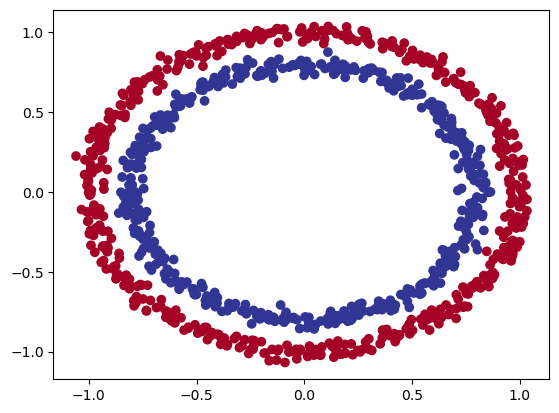

In [7]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0], y=X[:, 1], c=y, cmap=plt.cm.RdYlBu);

In [8]:
X.shape, y.shape

((1000, 2), (1000,))

In [9]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


In [10]:
import torch 
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [12]:



# 2. Building a model




In [13]:
# Standart PyTorch import
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [14]:
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2, out_features=5)
        self.layer2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, x):
        return self.layer2(self.layer1(x))

CM = CircleModel().to(device)
CM

CircleModel(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

In [15]:
CM = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

CM

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [16]:
untrained_predictions = CM(X_test.to(device))
print(f"Length of predictions: {len(untrained_predictions)}, Shape: {untrained_predictions.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_predictions[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[0.7303],
        [0.8320],
        [0.4721],
        [0.8035],
        [0.4850],
        [0.5470],
        [0.8228],
        [0.7561],
        [0.4720],
        [0.8389]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [17]:
# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=CM.parameters(), lr=0.1)

In [18]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

In [19]:
# View the frist 5 outputs of the forward pass on the test data
y_logits = CM(X_test.to(device))[:5]
y_logits

tensor([[0.7303],
        [0.8320],
        [0.4721],
        [0.8035],
        [0.4850]], device='cuda:0', grad_fn=<SliceBackward0>)

In [20]:

# Use sigmoid on model logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.6749],
        [0.6968],
        [0.6159],
        [0.6907],
        [0.6189]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [21]:
y_preds = torch.round(y_pred_probs)

y_pred_labels = torch.round(torch.sigmoid(CM(X_test.to(device))[:5]))

print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 1., 1., 1., 1.], device='cuda:0', grad_fn=<SqueezeBackward0>)

In [22]:
torch.manual_seed(42)

epochs = 401

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

#training loop
for epoch in range(epochs):

    ##train
    CM.train()

    # 1  Forward pass
    y_logits = CM(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # 2. Calculate loss/accuracy
    # loss = loss_fn(torch.sigmoid(y_logits), # Using nn.BCELoss you need torch.sigmoid()
    #                y_train) 

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3 optimizer zer grad
    optimizer.zero_grad()

    # 4 loss backward
    loss.backward()

    # 5 step
    optimizer.step()

    ###test
    CM.eval()
    with torch.inference_mode():
        #1 forawrd pass
        test_logits = CM(X_test).squeeze() 
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.74022, Accuracy: 50.00% | Test loss: 0.74472, Test acc: 50.00%
Epoch: 10 | Loss: 0.70705, Accuracy: 50.00% | Test loss: 0.71382, Test acc: 50.00%
Epoch: 20 | Loss: 0.69772, Accuracy: 58.88% | Test loss: 0.70437, Test acc: 53.00%
Epoch: 30 | Loss: 0.69494, Accuracy: 53.00% | Test loss: 0.70099, Test acc: 47.50%
Epoch: 40 | Loss: 0.69401, Accuracy: 52.12% | Test loss: 0.69943, Test acc: 47.50%
Epoch: 50 | Loss: 0.69362, Accuracy: 51.38% | Test loss: 0.69850, Test acc: 47.00%
Epoch: 60 | Loss: 0.69342, Accuracy: 51.50% | Test loss: 0.69783, Test acc: 46.50%
Epoch: 70 | Loss: 0.69330, Accuracy: 51.50% | Test loss: 0.69732, Test acc: 46.00%
Epoch: 80 | Loss: 0.69321, Accuracy: 51.25% | Test loss: 0.69690, Test acc: 46.50%
Epoch: 90 | Loss: 0.69315, Accuracy: 51.12% | Test loss: 0.69656, Test acc: 46.00%
Epoch: 100 | Loss: 0.69311, Accuracy: 51.12% | Test loss: 0.69628, Test acc: 46.50%
Epoch: 110 | Loss: 0.69308, Accuracy: 50.88% | Test loss: 0.69605, Test acc: 46.50%
Epo

In [23]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download")
else:
    print("Downloading helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary


helper_functions.py already exists, skipping download


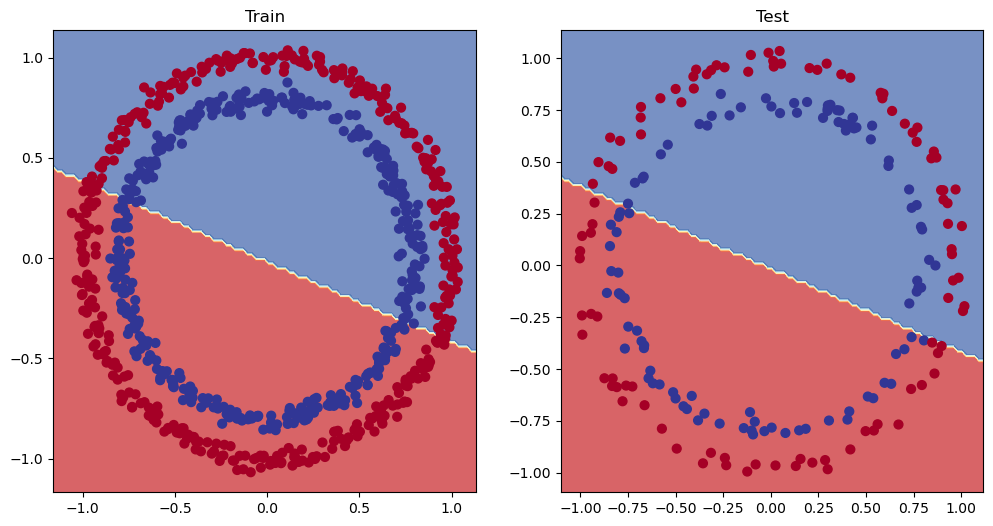

In [25]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(CM, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(CM, X_test, y_test)

In [26]:



### New model




In [27]:
class CircleModel2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)  ## add extra layer
        self.layer_3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, x):
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        return self.layer_3(self.layer_2(self.layer_1(x)))

CM2 = CircleModel2().to(device)

In [28]:
CM2

CircleModel2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [30]:
# loss_fn = nn.BCELoss() # Requires sigmoid on input
loss_fn = nn.BCEWithLogitsLoss() # Does not require sigmoid on input
optimizer = torch.optim.SGD(CM2.parameters(), lr=0.1)

In [33]:
torch.manual_seed(42)

epochs = 1001

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ## train

    CM2.train()
    
    #1 forward pass
    y_logits = CM2(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))  # logits -> prediction probabilities -> prediction labels

    # 2 calc loss/accuarcy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3 Optimizer zero grad
    optimizer.zero_grad()

    # 4 Loss backward
    loss.backward()

    # 5 optimizer step
    optimizer.step()

    CM2.eval()

    with torch.inference_mode():

        # 1 forawrd pass
        test_logits = CM2(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2 calc loss accuracy
        loss = loss_fn(y_logits, y_train)
        acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
        
    # Print out what's happening every 10 epochs
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69472, Test acc: 46.00%
Epoch: 100 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69472, Test acc: 46.00%
Epoch: 200 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69472, Test acc: 46.00%
Epoch: 300 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69472, Test acc: 46.00%
Epoch: 400 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69472, Test acc: 46.00%
Epoch: 500 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69472, Test acc: 46.00%
Epoch: 600 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69472, Test acc: 46.00%
Epoch: 700 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69472, Test acc: 46.00%
Epoch: 800 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69472, Test acc: 46.00%
Epoch: 900 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69472, Test acc: 46.00%
Epoch: 1000 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69472, Test acc: 46.00%


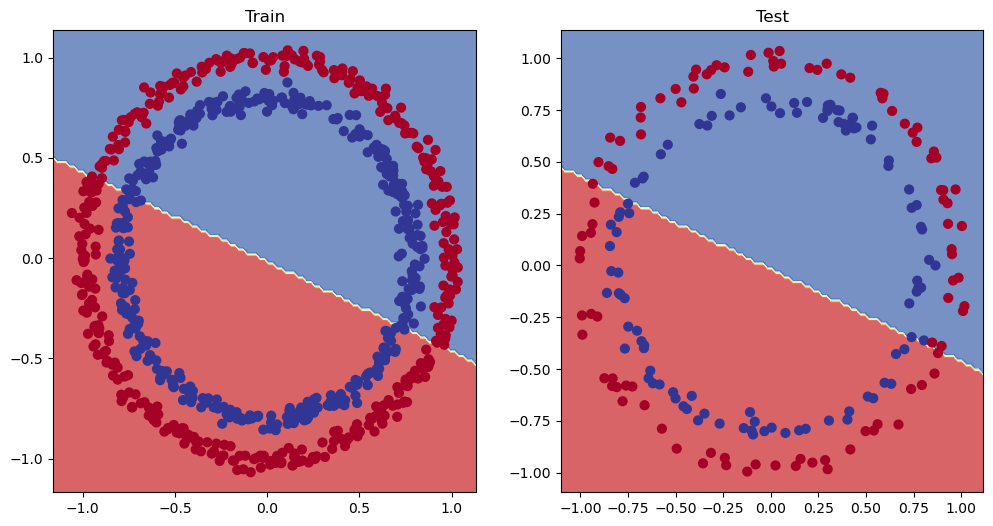

In [35]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(CM2, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(CM2, X_test, y_test)

In [36]:



# Preparing data to see if our model can model a straight line



In [37]:
# create some data
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias # linear regression formula

# check data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [38]:
train_split = int(0.8 * len(X_regression)) # 80% of data used for training set
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

# Check the lengths of each split
print(len(X_train_regression), 
    len(y_train_regression), 
    len(X_test_regression), 
    len(y_test_regression))

80 80 20 20


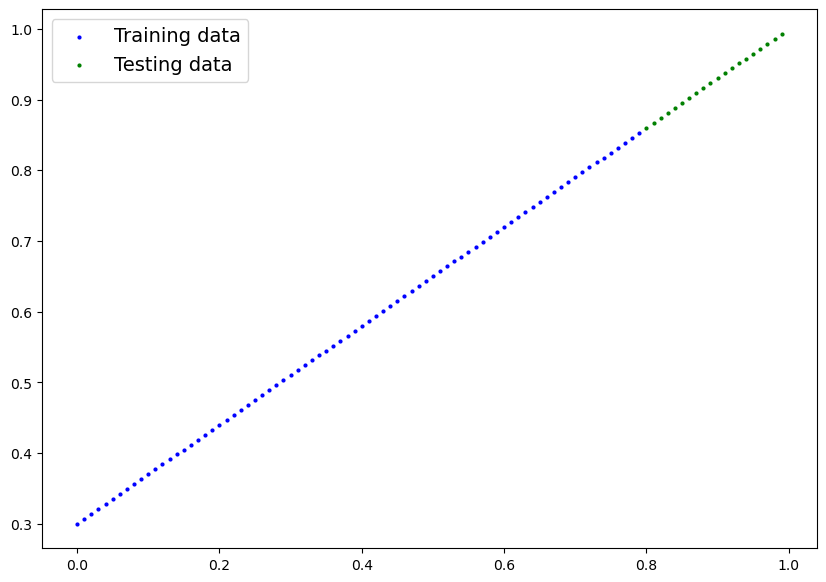

In [39]:
plot_predictions(train_data=X_train_regression,
    train_labels=y_train_regression,
    test_data=X_test_regression,
    test_labels=y_test_regression
);

In [40]:
CM3 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

CM3

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [42]:
# Loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(CM3.parameters(), lr=0.1)

In [45]:
#train
torch.manual_seed(42)

epochs = 1001


# Put data to target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
    ##train

    CM3.train()
    
    # 1 forward pass
    y_pred = CM3(X_train_regression)

    # 2 calc loss
    loss = loss_fn(y_pred, y_train_regression)

    # 3 Optimizer
    optimizer.zero_grad()

    # 4 loss back
    loss.backward()

    # 5 step
    optimizer.step()

    CM3.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_pred = CM3(X_test_regression)
        # 2. Calculate the loss 
        test_loss = loss_fn(test_pred, y_test_regression)

    # Print out what's happening
    if epoch % 100 == 0: 
        print(f"Epoch: {epoch} | Train loss: {loss:.5f}, Test loss: {test_loss:.5f}")

Epoch: 0 | Train loss: 0.04742, Test loss: 0.07619
Epoch: 100 | Train loss: 0.05222, Test loss: 0.10743
Epoch: 200 | Train loss: 0.06038, Test loss: 0.09909
Epoch: 300 | Train loss: 0.06016, Test loss: 0.10777
Epoch: 400 | Train loss: 0.05164, Test loss: 0.12524
Epoch: 500 | Train loss: 0.06152, Test loss: 0.05546
Epoch: 600 | Train loss: 0.05798, Test loss: 0.09413
Epoch: 700 | Train loss: 0.04730, Test loss: 0.03018
Epoch: 800 | Train loss: 0.04127, Test loss: 0.11101
Epoch: 900 | Train loss: 0.05254, Test loss: 0.08628
Epoch: 1000 | Train loss: 0.05216, Test loss: 0.09904


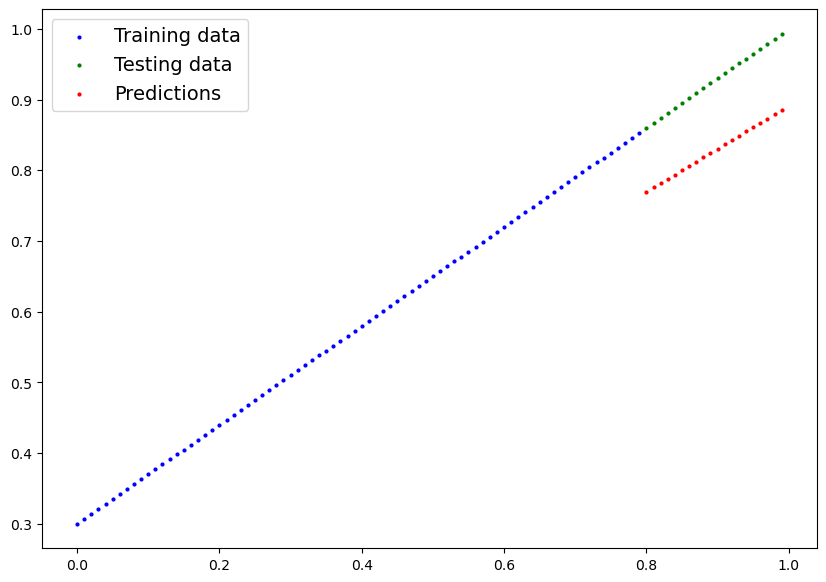

In [49]:
# Turn on evaluation mode
CM3.eval()

# Make predictions (inference)
with torch.inference_mode():
    y_preds = CM3(X_test_regression)

# Plot data and predictions with data on the CPU (matplotlib can't handle data on the GPU)
# (try removing .cpu() from one of the below and see what happens)
plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu());

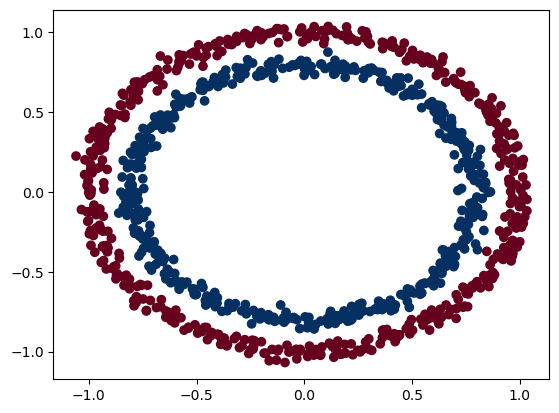

In [50]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples=1000,
    noise=0.03,
    random_state=42,
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu);

In [51]:
# Convert to tensors and split into train and test sets
import torch
from sklearn.model_selection import train_test_split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2,
                                                    random_state=42
)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [73]:
from torch import nn
class CircleModelV3(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function
        # Can also put sigmoid in the model 
        # This would mean you don't need to use it on the predictions
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
      # Intersperse the ReLU activation function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

CM4 = CircleModelV3().to(device)
print(CM4)

CircleModelV3(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [74]:
# Setup loss and optimizer 
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(CM4.parameters(), lr=0.1)

In [75]:
torch.manual_seed(42)
epochs = 10001

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):

    CM4.train()
    
    #1 forward pass
    y_logits = CM4(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # 2 calc loss and acc
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3 optimizer
    optimizer.zero_grad()

    # 4 loss back
    loss.backward()

    # 5 step
    optimizer.step()

    #test
    CM4.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = CM4(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits)) # logits -> prediction probabilities -> prediction labels
        # 2. Calculate loss and accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69295, Accuracy: 50.00% | Test Loss: 0.69319, Test Accuracy: 50.00%
Epoch: 100 | Loss: 0.69115, Accuracy: 52.88% | Test Loss: 0.69102, Test Accuracy: 52.50%
Epoch: 200 | Loss: 0.68977, Accuracy: 53.37% | Test Loss: 0.68940, Test Accuracy: 55.00%
Epoch: 300 | Loss: 0.68795, Accuracy: 53.00% | Test Loss: 0.68723, Test Accuracy: 56.00%
Epoch: 400 | Loss: 0.68517, Accuracy: 52.75% | Test Loss: 0.68411, Test Accuracy: 56.50%
Epoch: 500 | Loss: 0.68102, Accuracy: 52.75% | Test Loss: 0.67941, Test Accuracy: 56.50%
Epoch: 600 | Loss: 0.67515, Accuracy: 54.50% | Test Loss: 0.67285, Test Accuracy: 56.00%
Epoch: 700 | Loss: 0.66659, Accuracy: 58.38% | Test Loss: 0.66322, Test Accuracy: 59.00%
Epoch: 800 | Loss: 0.65160, Accuracy: 64.00% | Test Loss: 0.64757, Test Accuracy: 67.50%
Epoch: 900 | Loss: 0.62362, Accuracy: 74.00% | Test Loss: 0.62145, Test Accuracy: 79.00%
Epoch: 1000 | Loss: 0.56818, Accuracy: 87.75% | Test Loss: 0.57378, Test Accuracy: 86.50%
Epoch: 1100 | Loss: 0.

In [76]:
# Make predictions
CM4.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(CM4(X_test))).squeeze()
y_preds[:10], y[:10] # want preds in same format as truth labels

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

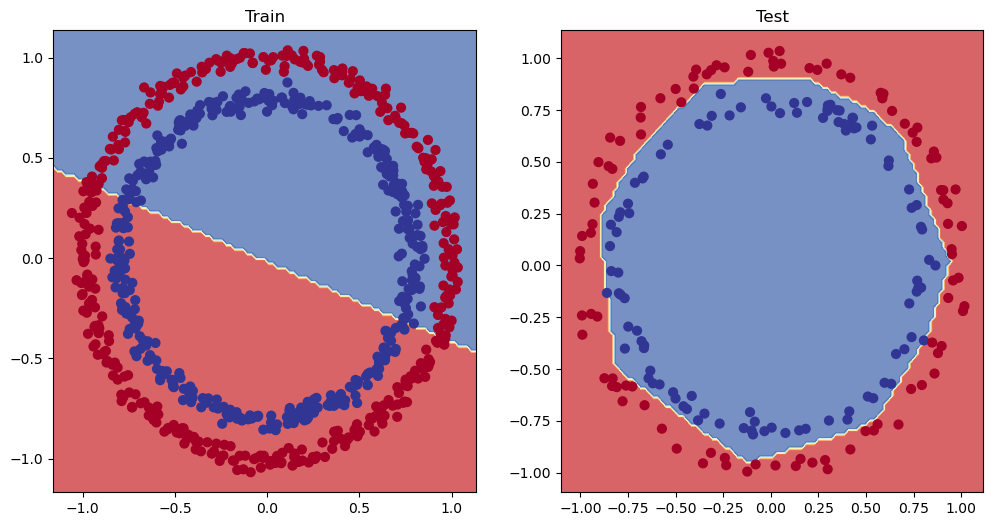

In [77]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(CM, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(CM4, X_test, y_test) # model_3 = has non-linearity

In [78]:
#Replicating non linear activation functions

In [79]:
# Create a toy tensor (similar to the data going into our model(s))
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

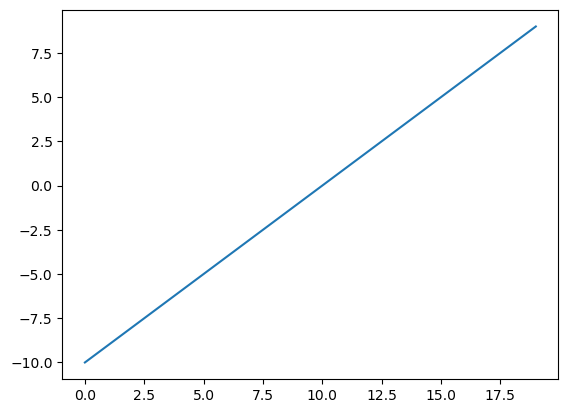

In [80]:
# Visualize the toy tensor
plt.plot(A);

In [81]:
def relu(x):
        return torch.maximum(torch.tensor(0), x)

In [82]:
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

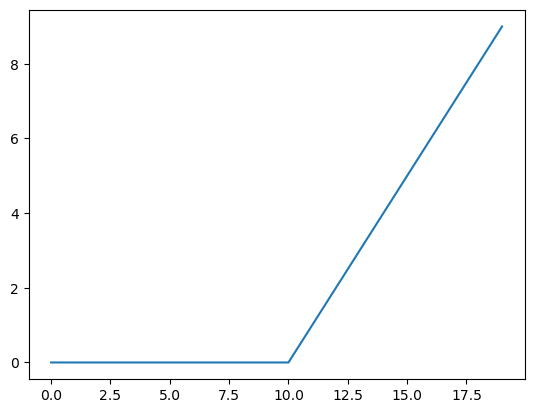

In [83]:
# Plot ReLU activated toy tensor
plt.plot(relu(A));

In [84]:
#sigmoid func
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

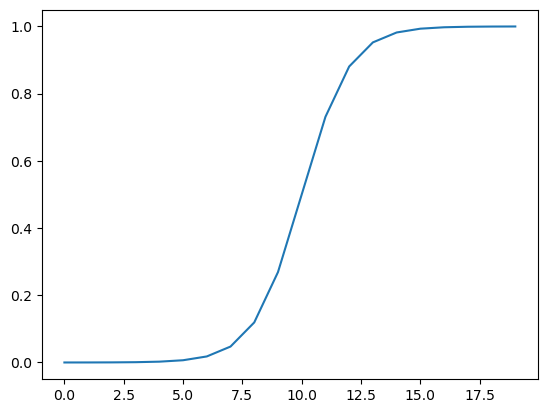

In [85]:
# Plot sigmoid activated toy tensor
plt.plot(sigmoid(A));

In [86]:




# Multiclass model




tensor([[ 6.4211, -3.4254],
        [ 3.8370, -5.4860],
        [ 7.4601, -2.7401],
        [ 7.3224, -5.6242],
        [-1.0547,  2.3842]]) tensor([0, 0, 0, 0, 2])


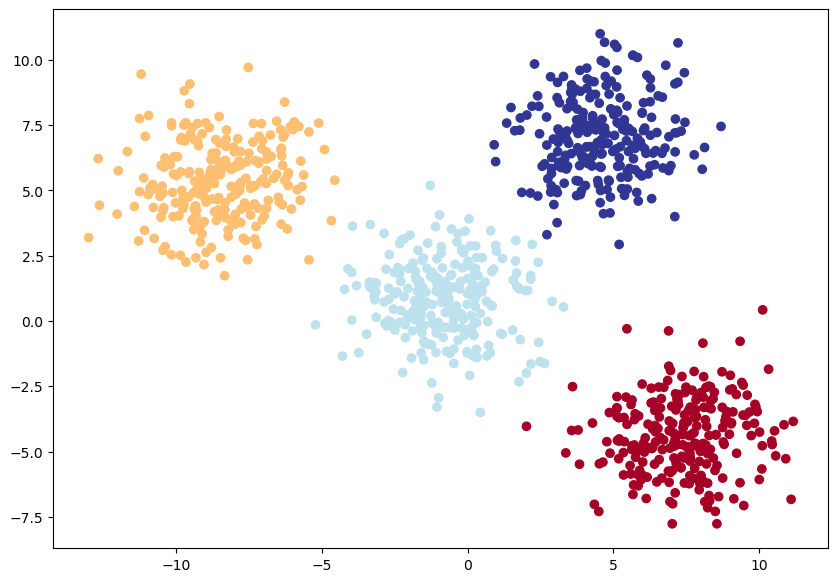

In [90]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 29

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
    n_features=NUM_FEATURES, # X features
    centers=NUM_CLASSES, # y labels 
    cluster_std=1.5, # give the clusters a little shake up (try changing this to 1.0, the default)
    random_state=RANDOM_SEED
)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
print(X_blob[:5], y_blob[:5])

# 3. Split into train and test sets
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
    y_blob,
    test_size=0.2,
    random_state=RANDOM_SEED
)

# 4. Plot data
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);

In [91]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [112]:
from torch import nn

class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(), # <- does our dataset require non-linear layers? (try uncommenting and see if the results change)
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(), # <- does our dataset require non-linear layers? (try uncommenting and see if the results change)
            nn.Linear(in_features=hidden_units, out_features=output_features), # how many classes are there?
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

BM = BlobModel(input_features=NUM_FEATURES,
        output_features=NUM_CLASSES,
        hidden_units=8).to(device)
BM

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [113]:
# Create loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(BM.parameters(), 
                            lr=0.1) # exercise: try changing the learning rate here and seeing what happens to the model's performance

In [114]:
# Perform a single forward pass on the data (we'll need to put it to the target device for it to work)
BM(X_blob_train.to(device))[:5]

tensor([[-0.3696, -1.0184, -0.9247, -0.3823],
        [-0.0638, -0.8702, -0.5162, -0.1126],
        [ 0.0568, -0.5880, -0.2714, -0.0720],
        [ 0.2313, -0.3080,  0.0883, -0.0237],
        [-0.4642, -0.9779, -1.0930, -0.4885]], device='cuda:0',
       grad_fn=<SliceBackward0>)

In [115]:
# How many elements in a single prediction sample?
BM(X_blob_train.to(device))[0].shape, NUM_CLASSES 

(torch.Size([4]), 4)

In [116]:
# Make prediction logits with model
y_logits = BM(X_blob_test.to(device))

# Perform softmax calculation on logits across dimension 1 to get prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1) 
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.2650, -0.4565, -0.6843, -0.5412],
        [-0.8257, -1.0899, -1.7764, -1.1078],
        [-0.8712, -0.8674, -1.6059, -0.9806],
        [ 0.2611, -0.2362,  0.1762,  0.0111],
        [-0.3937, -0.8799, -0.9606, -0.4337]], device='cuda:0',
       grad_fn=<SliceBackward0>)
tensor([[0.3085, 0.2547, 0.2028, 0.2340],
        [0.3438, 0.2640, 0.1329, 0.2593],
        [0.2959, 0.2970, 0.1419, 0.2652],
        [0.3025, 0.1840, 0.2779, 0.2356],
        [0.3182, 0.1957, 0.1805, 0.3057]], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [117]:
# Sum the first sample output of the softmax activation function 
torch.sum(y_pred_probs[0])

tensor(1.0000, device='cuda:0', grad_fn=<SumBackward0>)

In [118]:
# Which class does the model think is *most* likely at the index 0 sample?
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([0.3085, 0.2547, 0.2028, 0.2340], device='cuda:0',
       grad_fn=<SelectBackward0>)
tensor(0, device='cuda:0')


In [119]:
# Fit the model
torch.manual_seed(42)

# Set number of epochs
epochs = 101

# Put data to target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    ### Training
    BM.train()

    # 1. Forward pass
    y_logits = BM(X_blob_train) # model outputs raw logits 
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # go from logits -> prediction probabilities -> prediction labels
    # print(y_logits)
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_blob_train) 
    acc = accuracy_fn(y_true=y_blob_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    BM.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = BM(X_blob_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      # 2. Calculate test loss and accuracy
      test_loss = loss_fn(test_logits, y_blob_test)
      test_acc = accuracy_fn(y_true=y_blob_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%") 

Epoch: 0 | Loss: 1.45872, Acc: 23.12% | Test Loss: 1.36991, Test Acc: 26.00%
Epoch: 10 | Loss: 0.94747, Acc: 63.25% | Test Loss: 0.93551, Test Acc: 63.00%
Epoch: 20 | Loss: 0.69725, Acc: 69.62% | Test Loss: 0.72044, Test Acc: 67.00%
Epoch: 30 | Loss: 0.61893, Acc: 70.88% | Test Loss: 0.64323, Test Acc: 68.50%
Epoch: 40 | Loss: 0.56591, Acc: 72.12% | Test Loss: 0.58847, Test Acc: 69.50%
Epoch: 50 | Loss: 0.52283, Acc: 72.62% | Test Loss: 0.54336, Test Acc: 70.50%
Epoch: 60 | Loss: 0.48559, Acc: 73.25% | Test Loss: 0.50403, Test Acc: 71.00%
Epoch: 70 | Loss: 0.45168, Acc: 73.50% | Test Loss: 0.46817, Test Acc: 71.50%
Epoch: 80 | Loss: 0.41980, Acc: 95.75% | Test Loss: 0.43455, Test Acc: 95.50%
Epoch: 90 | Loss: 0.38924, Acc: 97.88% | Test Loss: 0.40244, Test Acc: 97.00%
Epoch: 100 | Loss: 0.35977, Acc: 98.25% | Test Loss: 0.37159, Test Acc: 97.00%


In [120]:
# Make predictions
BM.eval()
with torch.inference_mode():
    y_logits = BM(X_blob_test)

# View the first 10 predictions
y_logits[:10]

tensor([[-1.6745, -3.1962, -0.3171, -0.9648],
        [-7.0662, -7.5305, -1.7272,  2.3825],
        [ 0.3032, -8.0993, -2.9842, -2.8009],
        [-0.4798,  0.2496,  1.0686, -1.1911],
        [ 3.5707, -5.7663, -2.3612, -4.7379],
        [-0.4438,  0.9675,  0.7513, -0.6344],
        [-7.7573, -8.4243, -2.0892,  2.7565],
        [ 4.6925, -7.2081, -3.2888, -5.7706],
        [-7.8141, -8.5762, -2.1822,  2.7491],
        [-4.1213, -3.9612, -0.3777,  0.6725]], device='cuda:0')

In [121]:
# Turn predicted logits in prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)

# Turn prediction probabilities into prediction labels
y_preds = y_pred_probs.argmax(dim=1)

# Compare first 10 model preds and test labels
print(f"Predictions: {y_preds[:10]}\nLabels: {y_blob_test[:10]}")
print(f"Test accuracy: {accuracy_fn(y_true=y_blob_test, y_pred=y_preds)}%")

Predictions: tensor([2, 3, 0, 2, 0, 1, 3, 0, 3, 3], device='cuda:0')
Labels: tensor([2, 3, 0, 2, 0, 1, 3, 0, 3, 3], device='cuda:0')
Test accuracy: 97.0%


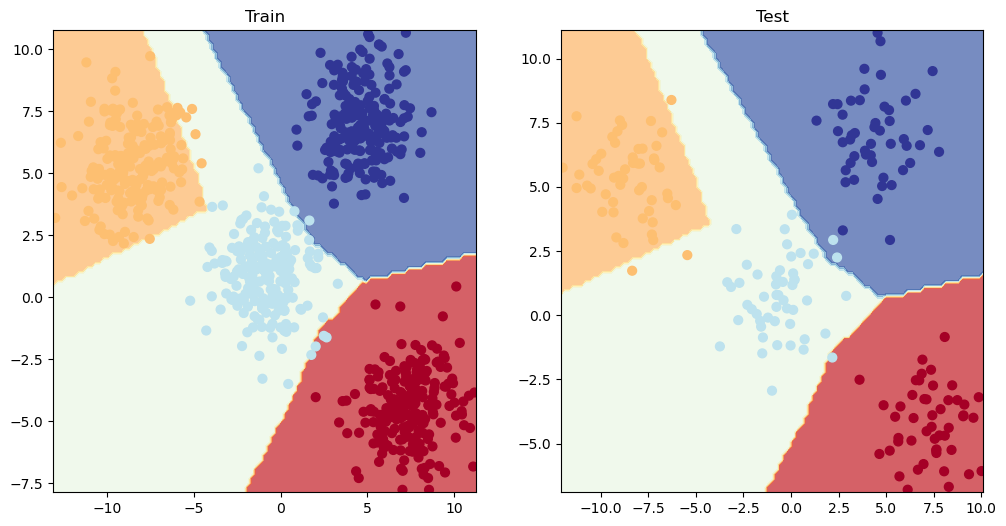

In [122]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(BM, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(BM, X_blob_test, y_blob_test)

In [111]:
try:
    from torchmetrics import Accuracy
except:
    !pip install torchmetrics==0.9.3 # this is the version we're using in this notebook (later versions exist here: https://torchmetrics.readthedocs.io/en/stable/generated/CHANGELOG.html#changelog)
    from torchmetrics import Accuracy

# Setup metric and make sure it's on the target device
torchmetrics_accuracy = Accuracy(task='multiclass', num_classes=4).to(device)

# Calculate accuracy
torchmetrics_accuracy(y_preds, y_blob_test)

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


ModuleNotFoundError: No module named 'torchmetrics'